# Template Clustering Image
load gambar -> scale + PCA -> KMeans -> evaluasi -> plot -> insight


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


## Load data


In [92]:
# kalau gambar di folder: data/nama_kelas/gambar.jpg
# from pathlib import Path
# from PIL import Image
# paths = sorted(Path("data").rglob("*.jpg"))
# images = np.array([np.array(Image.open(p).convert("RGB").resize((64, 64))) for p in paths])
# X = images.reshape(len(images), -1) / 255.0
# y_true = np.array([p.parent.name for p in paths])


In [ ]:
## Folder gambar tanpa label: semua gambar boleh langsung berada dalam satu folder.
## Aktifkan hanya satu loader. Hapus satu # di awal tiap baris untuk memakai cell ini.
# from pathlib import Path
# from PIL import Image
#
# folder = Path("data/gambar")  # GANTI path folder
# extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")
# paths = sorted(p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in extensions)  # semua gambar
# # paths = paths[:5000]  # OPSIONAL: sampel 5000 gambar pertama; ubah angka atau beri #
#
# images = []
# for p in paths:
#     with Image.open(p) as img:
#         images.append(np.array(img.convert("RGB").resize((64, 64))))
# images = np.array(images)
# X = images.reshape(len(images), -1).astype(np.float32) / 255.0
# y_true = None  # tidak ada label asli; tetap bisa clustering
# print(X.shape)


In [93]:
# Load data .npz: semua data atau sampel
# Aktifkan cell ini saat memakai NPZ dan nonaktifkan loader Digits/folder.
data = np.load("D:/Tugas Kuliah/Tugas Kuliah Sem 5/Data Mining II/UTS/Data Latihan UTS Datmin/Image/Data Latihan Datmin II (Image).npz")
images, y_true = data["x_train"], data["y_train"]  # semua data
images, y_true = images[:5000], y_true[:5000]  # sampel; ubah 5000 atau beri # untuk semua data
X = images.reshape(len(images), -1) / 255.0
print(X.shape)


(5000, 784)


In [ ]:
## Alternatif ZIP gambar: contoh struktur nama_kelas/gambar.jpg.
## Jalankan import di atas dan nonaktifkan loader NPZ/folder saat memakai ini.
## Hapus satu # di awal setiap baris untuk mengaktifkan cell.
# from zipfile import ZipFile
# from pathlib import PurePosixPath
# from io import BytesIO
# from PIL import Image
#
# with ZipFile("data_image.zip") as z:  # GANTI path ZIP
#     extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")
#     files = sorted(n for n in z.namelist() if n.lower().endswith(extensions) and not n.startswith("__MACOSX/"))  # semua gambar
#     # files = files[:5000]  # OPSIONAL: sampel 5000 gambar pertama; ubah angkanya
#     images = []
#     for n in files:
#         with Image.open(BytesIO(z.read(n))) as img:
#             images.append(np.array(img.convert("RGB").resize((64, 64))))
#     images = np.array(images)
#     y_true = np.array([PurePosixPath(n).parent.name for n in files])  # label dari nama folder
#
# X = images.reshape(len(images), -1).astype(np.float32) / 255.0
# print(X.shape)


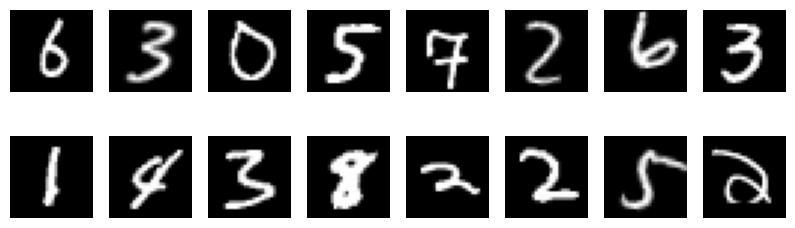

In [94]:
fig, ax = plt.subplots(2, 8, figsize=(10, 3))
for i, a in enumerate(ax.flat):
    a.imshow(images[i], cmap="gray")
    a.axis("off")
plt.show()


## Preprocessing


In [95]:
from sklearn.preprocessing import RobustScaler

X_scaled = RobustScaler().fit_transform(X)  # kalau ada outlier

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_.sum())


0.9949177807325955


## Tentukan k


  0%|          | 0/13 [00:00<?, ?it/s]

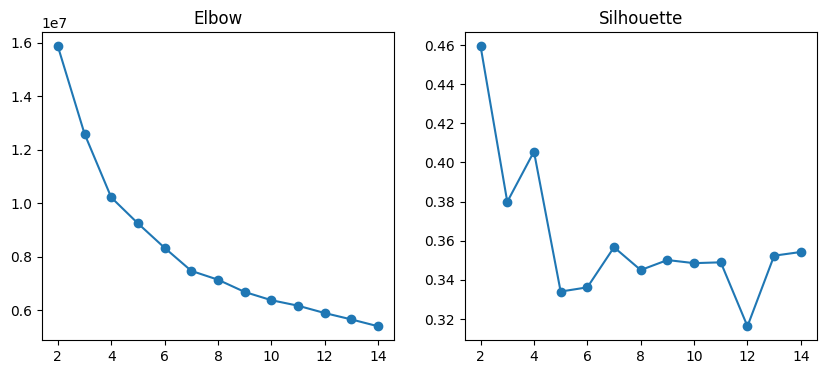

In [96]:
from tqdm.auto import tqdm
ks = range(2, 15)
inertia, sil = [], []
for k in tqdm(ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, "o-"); ax[1].set_title("Silhouette")
plt.show()


k dipilih = ... karena ... (isi sendiri dari grafik)

## KMeans + evaluasi


In [97]:
k = 10   # GANTI
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

print("Silhouette    :", silhouette_score(X_pca, labels))
print("Davies-Bouldin:", davies_bouldin_score(X_pca, labels))
print(pd.Series(labels).value_counts().sort_index())


Silhouette    : 0.34856441912706704
Davies-Bouldin: 1.2486602382586454
0     175
1     266
2     459
3     323
4     338
5     272
6     435
7     225
8    2161
9     346
Name: count, dtype: int64


## Plot cluster


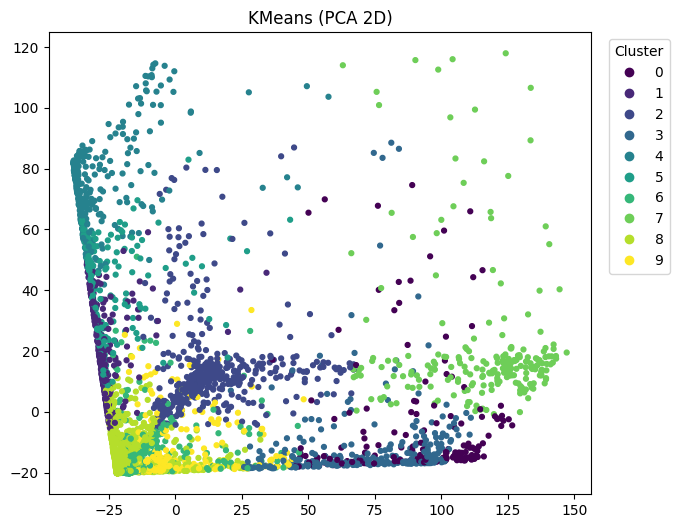

In [101]:
p2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(p2[:, 0], p2[:, 1], c=labels, s=12)
plt.legend(*sc.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("KMeans (PCA 2D)")
plt.show()


## Insight tiap cluster


In [ ]:
fig, ax = plt.subplots(1, k, figsize=(2 * k, 2.5))
for c in range(k):
    mean_img = images[labels == c].mean(axis=0).astype(images.dtype)
    ax[c].imshow(mean_img, cmap="gray")
    ax[c].set_title(f"C{c} (n={np.sum(labels == c)})", fontsize=8)
    ax[c].axis("off")
plt.show()

# bandingin ke label asli kalau ada
if y_true is not None:
    display(pd.crosstab(labels, y_true))


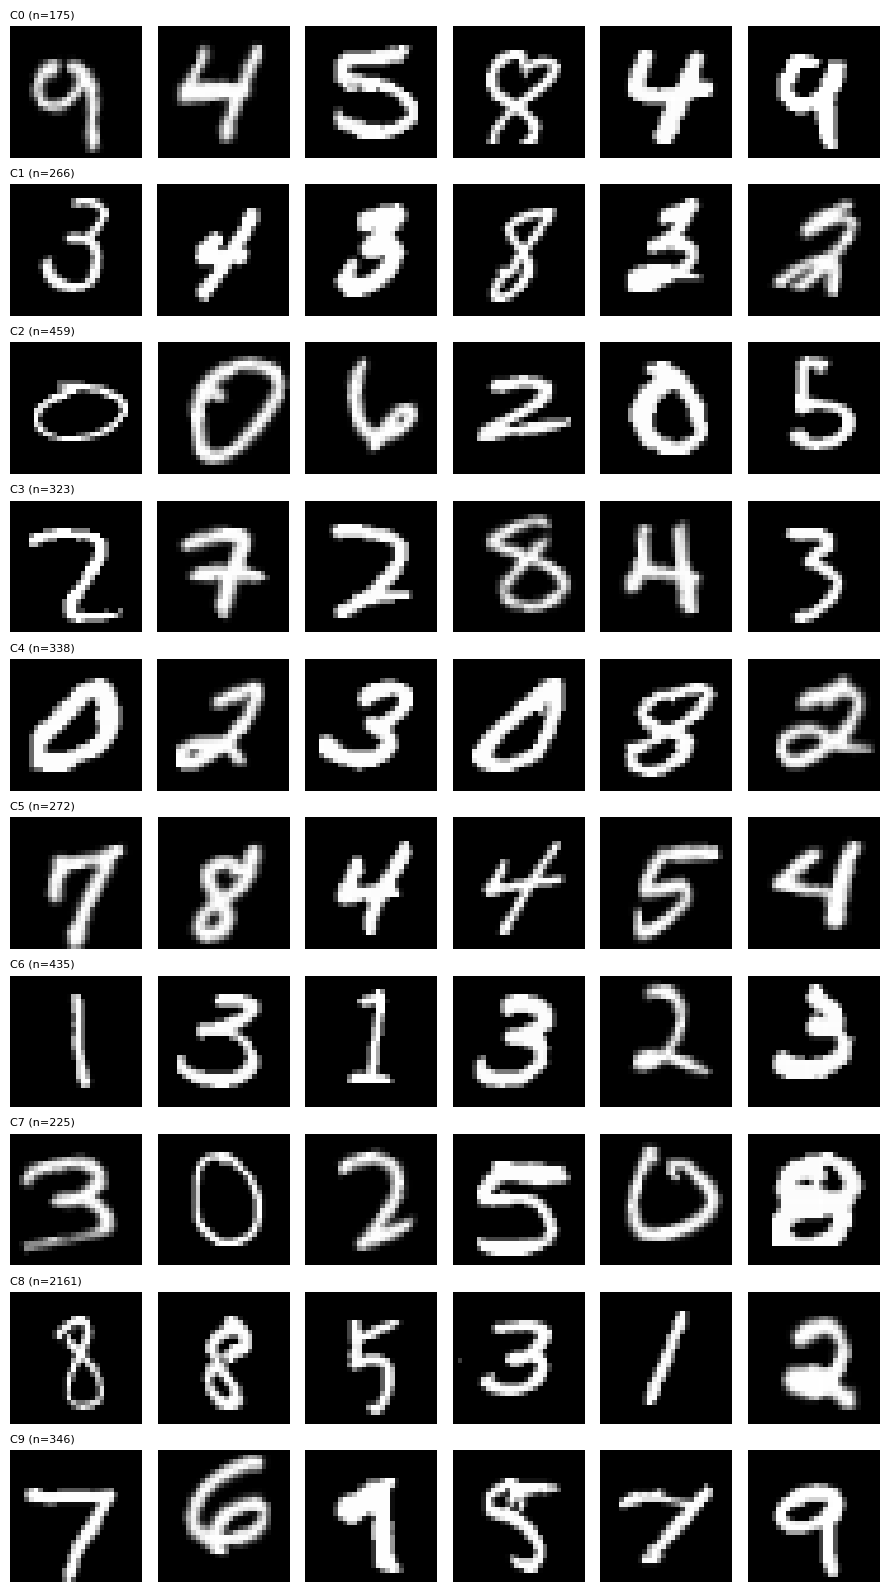

In [100]:
# Contoh gambar asli tiap cluster (maksimal 6 gambar)
rng = np.random.default_rng(42)
fig, ax = plt.subplots(k, 6, figsize=(9, 1.6 * k), squeeze=False)
for a in ax.flat:
    a.axis("off")
for c in range(k):
    members = np.flatnonzero(labels == c)
    idx = rng.choice(members, size=min(6, len(members)), replace=False)
    for a, i in zip(ax[c], idx):
        a.imshow(images[i], cmap="gray")
    ax[c, 0].set_title(f"C{c} (n={len(members)})", fontsize=8, loc="left")
plt.tight_layout()
plt.show()


## Kesimpulan
- Evaluasi: silhouette = ..., DBI = ...
- Cluster 0: ...
- Cluster 1: ...
- Cluster yang campur: ...
